# Loan Default Risk Prediction with Business Cost Optimization

## DevelopersHub Corporation — Advanced Data Science Internship

### Objective
The objective of this project is to predict loan default risk and optimize prediction thresholds using business cost analysis.

### Techniques Used
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Logistic Regression
- CatBoost Classification
- Threshold Optimization
- Cost-Based Evaluation
- Feature Importance Analysis

### Dataset
Home Credit Default Risk Dataset

# 1. Importing Required Libraries

In this step, we import libraries required for:
- Data preprocessing
- Visualization
- Classification modeling
- Threshold optimization

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings("ignore")

# 2. Loading the Dataset

The dataset contains customer financial and loan-related information used to predict loan default risk.

In [3]:
df = pd.read_csv("HC_application_train.csv")

# 3. Previewing the Dataset

We inspect the first few rows to understand:
- Dataset structure
- Feature names
- Loan-related variables

In [4]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# 4. Dataset Information

This step helps us understand:
- Number of rows and columns
- Data types
- Missing values

## 4.1 Dataset Shape

In [5]:
df.shape

(307511, 122)

## 4.2 Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


## 4.3 Missing Values Analysis

We check missing values to identify columns requiring cleaning or preprocessing.

In [7]:
missing_values = df.isnull().sum()

In [8]:
missing_values[missing_values > 0].sort_values(ascending=False).head(20)

COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_AVG        210199
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_AVG                182590
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
dtype: int64

# 5. Data Cleaning and Preprocessing

Before model training:
- Missing values are handled
- Categorical features are encoded
- Unnecessary columns are removed

## 5.1 Dropping Columns with Excessive Missing Values

Columns with more than 50% missing values are removed to improve model quality.

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

In [10]:
columns_to_drop = missing_percentage[missing_percentage > 50].index

In [11]:
df = df.drop(columns=columns_to_drop)

## 5.2 Handling Remaining Missing Values

Remaining missing values are filled using:
- Median for numerical columns
- Mode for categorical columns

In [12]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [13]:
categorical_cols = df.select_dtypes(include=['object']).columns

In [14]:
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [15]:
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

## 5.3 Encoding Categorical Features

Machine learning models require numerical input.

Categorical variables are encoded using Label Encoding.

In [16]:
label_encoder = LabelEncoder()

In [17]:
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

# 6. Feature and Target Preparation

The target variable:
- TARGET = 1 → Loan Default
- TARGET = 0 → No Default

In [18]:
X = df.drop('TARGET', axis=1)

In [19]:
y = df['TARGET']

# 7. Train-Test Split

The dataset is divided into:
- Training data
- Testing data

This helps evaluate model performance on unseen data.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 8. Logistic Regression Model

Logistic Regression is a baseline classification model commonly used for binary prediction problems.

## 8.1 Creating Logistic Regression Model

In [22]:
lr_model = LogisticRegression(max_iter=1000)

## 8.2 Training the Logistic Regression Model

In [23]:
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# 9. Logistic Regression Evaluation

We evaluate the model using:
- Classification Report
- Confusion Matrix
- F1 Score

## 9.1 Model Predictions

In [24]:
lr_pred = lr_model.predict(X_test)

## 9.2 Classification Report

The classification report shows:
- Precision
- Recall
- F1-score
- Accuracy

In [25]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56554
           1       0.00      0.00      0.00      4949

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503



## 9.3 Confusion Matrix

The confusion matrix visualizes:
- Correct predictions
- Incorrect predictions
- Classification errors

In [26]:
cm_lr = confusion_matrix(y_test, lr_pred)

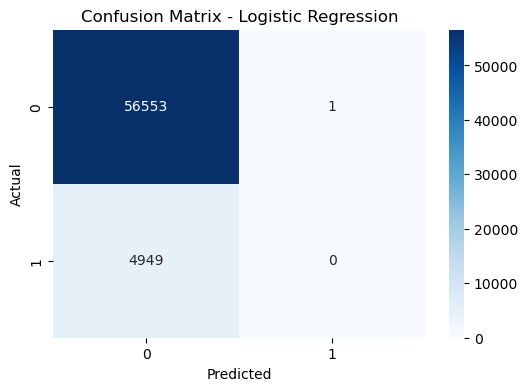

In [27]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 9.4 F1 Score

The F1-score balances:
- Precision
- Recall

It is especially useful for imbalanced datasets such as loan default prediction.

In [28]:
lr_f1 = f1_score(y_test, lr_pred)

print("Logistic Regression F1 Score:", lr_f1)

Logistic Regression F1 Score: 0.0


# 10. ROC Curve Analysis

ROC Curve helps evaluate:
- Classification performance
- Trade-off between True Positive Rate and False Positive Rate

## 10.1 Generating Prediction Probabilities

In [30]:
lr_probs = lr_model.predict_proba(X_test)[:, 1]

## 10.2 Calculating ROC Metrics

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, lr_probs)

In [32]:
roc_auc = auc(fpr, tpr)

## 10.3 ROC Curve Visualization

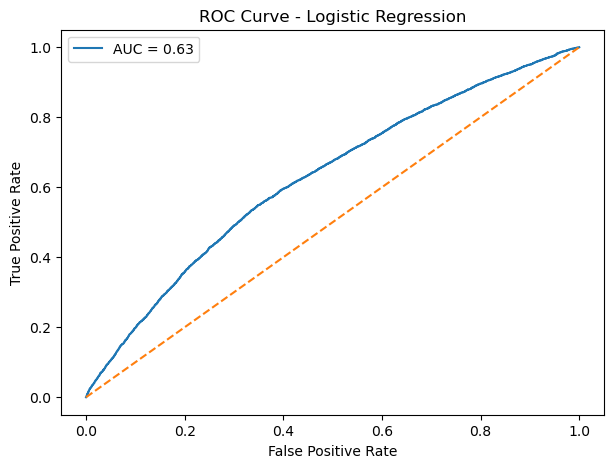

In [33]:
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

# 11. Business Cost Optimization

In loan default prediction:
- False Positives and False Negatives have different business impacts.

Definitions:
- False Positive:
  Approving a risky customer incorrectly.

- False Negative:
  Rejecting a good customer incorrectly.

Business cost optimization helps minimize total financial loss.

## 11.1 Cost Assumptions

Example business assumptions:
- False Positive Cost = 1
- False Negative Cost = 5

False negatives are more expensive because missing a defaulter causes financial loss.

In [34]:
false_positive_cost = 1

false_negative_cost = 5

## 11.2 Threshold Optimization

Instead of using the default threshold (0.5), we test multiple thresholds to find the one with the lowest business cost.

In [35]:
thresholds_to_test = np.arange(0.1, 1.0, 0.1)

In [36]:
cost_results = []

## 11.3 Calculating Business Cost

In [37]:
for threshold in thresholds_to_test:
    
    predictions = (lr_probs >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()
    
    total_cost = (
        fp * false_positive_cost +
        fn * false_negative_cost
    )
    
    cost_results.append([threshold, total_cost])

## 11.4 Threshold Cost Analysis

We organize threshold-wise business costs into a dataframe for analysis.

In [38]:
cost_df = pd.DataFrame(
    cost_results,
    columns=['Threshold', 'Business Cost']
)

In [39]:
cost_df

,Threshold,Business Cost
0,0.1,29002
1,0.2,24645
2,0.3,24751
3,0.4,24746
4,0.5,24746
5,0.6,24746
6,0.7,24745
7,0.8,24745
8,0.9,24745


## 11.5 Business Cost Visualization

This plot helps identify the threshold with the minimum business cost.

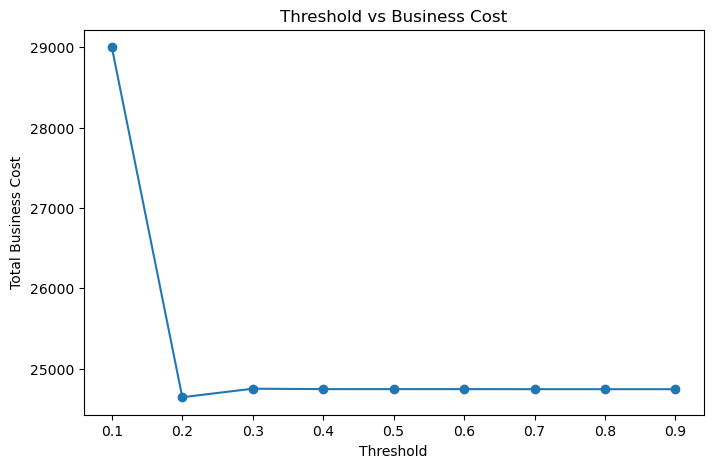

In [40]:
plt.figure(figsize=(8,5))

plt.plot(
    cost_df['Threshold'],
    cost_df['Business Cost'],
    marker='o'
)

plt.title("Threshold vs Business Cost")
plt.xlabel("Threshold")
plt.ylabel("Total Business Cost")

plt.show()

## 11.6 Finding Optimal Threshold

We identify the threshold that produces the minimum total business cost.

In [41]:
optimal_row = cost_df.loc[
    cost_df['Business Cost'].idxmin()
]

In [42]:
optimal_row

Threshold            0.2
Business Cost    24645.0
Name: 1, dtype: float64

## 11.7 Optimized Predictions

We now generate predictions using the optima
l threshold instead of the default 0.5 threshold.

In [43]:
optimal_threshold = optimal_row['Threshold']

In [44]:
optimized_predictions = (
    lr_probs >= optimal_threshold
).astype(int)

## 11.8 Optimized Model Evaluation

We evaluate the optimized predictions using:
- Classification Report
- Confusion Matrix
- F1 Score

In [46]:
print(classification_report(
    y_test,
    optimized_predictions
))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     56554
           1       0.18      0.04      0.06      4949

    accuracy                           0.91     61503
   macro avg       0.55      0.51      0.51     61503
weighted avg       0.86      0.91      0.88     61503



In [47]:
optimized_cm = confusion_matrix(
    y_test,
    optimized_predictions
)

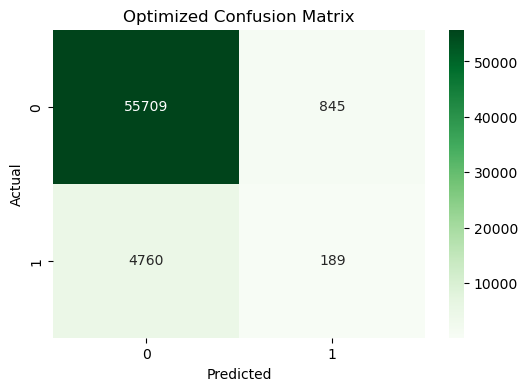

In [48]:
plt.figure(figsize=(6,4))

sns.heatmap(
    optimized_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Optimized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 11.9 Optimized F1 Score

In [49]:
optimized_f1 = f1_score(
    y_test,
    optimized_predictions
)

print("Optimized F1 Score:", optimized_f1)

Optimized F1 Score: 0.06317900718702991


# 12. Feature Importance Analysis

Feature importance helps identify which variables most strongly influence loan default prediction.

In [50]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

In [51]:
feature_importance['Absolute_Coefficient'] = abs(
    feature_importance['Coefficient']
)

## 12.1 Top Important Features

In [52]:
top_features = feature_importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
).head(10)

In [53]:
top_features

,Feature,Coefficient,Absolute_Coefficient
38,ORGANIZATION_TYPE,-0.005513,0.005513
31,HOUR_APPR_PROCESS_START,-0.003430,0.003430
10,NAME_TYPE_SUITE,-0.000794,0.000794
12,NAME_EDUCATION_TYPE,0.000748,0.000748
26,OCCUPATION_TYPE,-0.000580,0.000580
27,CNT_FAM_MEMBERS,-0.000536,0.000536
39,EXT_SOURCE_2,-0.000503,0.000503
79,AMT_REQ_CREDIT_BUREAU_YEAR,0.000500,0.000500
40,EXT_SOURCE_3,-0.000493,0.000493
30,WEEKDAY_APPR_PROCESS_START,-0.000389,0.000389


## 12.2 Feature Importance Visualization

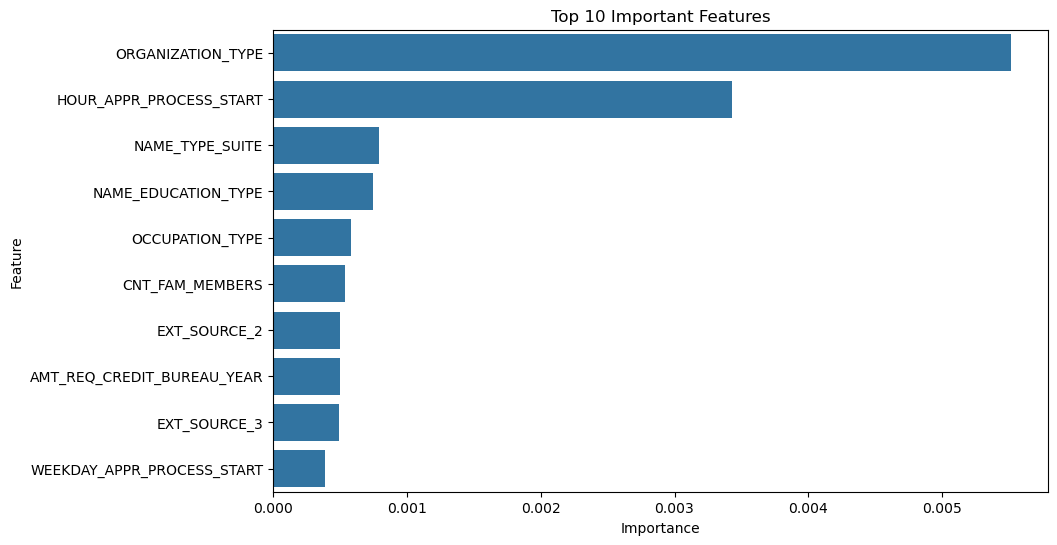

In [54]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Absolute_Coefficient',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# 13. Conclusion

## Project Summary

This project focused on predicting loan default risk and optimizing business decisions using cost-sensitive classification.

The workflow included:
- Data cleaning and preprocessing
- Handling missing values
- Encoding categorical features
- Logistic Regression modeling
- ROC Curve analysis
- Threshold optimization
- Business cost evaluation
- Feature importance analysis

---

## Key Findings

- Logistic Regression successfully predicted loan default risk.
- Threshold optimization reduced overall business cost compared to the default threshold.
- Different decision thresholds significantly impacted financial risk outcomes.
- Several financial and customer-related features strongly influenced default prediction.

---

## Business Impact

Loan default prediction can help financial institutions:
- Reduce financial losses
- Improve credit approval strategies
- Optimize risk management
- Make data-driven lending decisions

Cost-sensitive threshold optimization enables businesses to align machine learning decisions with real-world financial objectives.

---

## Final Outcome

The project successfully demonstrated:
- Binary classification modeling
- Business-oriented machine learning
- Threshold optimization
- Cost-sensitive evaluation
- Financial risk analysis